# <span style="color:blue"><b>Table of Content</b></span>
### 1 [Introduction](#Introduction)
### 2 [Definition and Formula](#Definition-and-Formula)
### 3 [Financial Report Data Collection](#Financial-Report-Data-Collection)
### 4 [Projection of Future Cash Flow](#Projection-of-Future-Cash-Flow)
### 5 [Discount the Future Cash Flow and Terminal Value to Present](#Discount-the-Future-Cash-Flow-and-Terminal-Value-to-Present)
### 6 [Conclusion](#Conclusion)

## Reference:
* <a href='https://www.nasdaq.com/market-activity/stocks/aapl'>Apple (AAPL) Inc. Key Information on Nasdaq</a>
* <a href='https://valueinvesting.io/AAPL/valuation/wacc'>AAPL WACC% (valueinvesting.io)</a>
* <a href='https://www.amazon.com/Corporate-Financial-Management-6th-Edition/dp/1292140445'>Corporate Financial Management, 6th E., Glen Arnold, 2019 Wiley </a>
* <a href='https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/vebitda.html'>Enterprise Value Multiples by Sector (NYU Stern School of Business)</a>

# Introduction

<b>Apple (AAPL)</b> Inc. is an American multinational technology company headquartered in Cupertino, California. Apple is the world's largest technology company by revenue, with US$394.3 billion in 2022 revenue. In this notebook, will discuss the concept and calculation of intrinsic value with the AAPL financial data from financialmodelingprep.com.


# Definition and Formula

The <b>Intrinsic Value</b> aka Corporate Value or Enterprise Value, is the add up of present value of future free cash flow(DCF) from operations and present value of terminal value(PVTV) aka non-operating assets. This is a relatively simple method to value a corporation.

### $$ Intrinsic Value = DCF + PVTV$$

<b>Discounted cash flow (DCF)</b> is a popular method used in feasibility studies, corporate acquisitions, and stock market valuation. This method is based on the theory that an asset's value is equal to all future cash flows derived from that asset. These cash flows must be discounted to the present value at a discount rate representing the cost of capital, such as the interest rate(usually the WACC). 

### $$ DCF = \frac{CF _{1} }{(1+r) ^{1}}+\frac{CF _{2} }{(1+r) ^{2}}+\frac{CF _{n} }{(1+r) ^{n}}$$
### $$ DCF =  \sum_{i=1}^n \frac{CF_{i} }{(1+r) ^{i}}  $$ <br>Where:
<pre>    DCF: Discounted Cash Flow
    CFi: Cash Flow of period i
    r: interest rate, WACC
    i: nth term of period start from 1
    n: time in years before future cash flow occurs</pre>

<b>Terminal value (TV)</b> is the estimated value of a business beyond the explicit forecast period. It is a critical part of the financial model, as it typically makes up a large percentage of the total value of a business. 

### $$ PVTV = \frac{EBITDA \times Exit Multiple}{(1+g)^{n}} $$<br>Where:
<pre>    PVTV: Present Value of Terminal value
    EBITDA: Last year EBITDA
    Exit Multiple: Multiply factor that is common for similar firms
    g: Growth rate
    n: Period of time
</pre>

# Financial Report Data Collection

In [25]:
import pandas as pd
import numpy as np
import requests
import os   # 要裝python-dotenv
import math
import plotly.express as px

from IPyth大TML("<style>.container { width:100% !important; }</style>"))

#!pip install -U jupyter
#!pip install -U plotly
# get your free FMP API key from https://financialmodelingprep.com
FMP_API_KEY = "3OcaNunQjdLSiHgJGQ3sfyTowxyh268K" #os.environ['FMP_API_KEY'] # setup key in .zshrc

SyntaxError: unmatched ')' (1622908298.py, line 8)

In [ ]:
# get cash flow statement API data
response = requests.get(f'https://financialmodelingprep.com/api/v3/cash-flow-statement/AAPL?limit=120&apikey={FMP_API_KEY}')

In [ ]:
year = []
cashflow = []
for r in response.json():
    year.insert(0, int(r['calendarYear']))
    cashflow.insert(0, float(r['freeCashFlow']))

In [ ]:
df = pd.DataFrame(data={'Year':year,
                        'CashFlow':cashflow}) #.set_index('Year')
df

In [ ]:
fig = px.scatter(df, x=df['Year'], y="CashFlow", trendline="ols", title="Apple Inc. Free Cash Flow 2018-2022")
fig.update_layout(xaxis = dict(tickmode='linear', tick0=1, dtick=1 ) )
fig.show()

# Projection of Future Cash Flow
Assume the current uptrend could continue stably in coming 5 years, forecasting the cash flow is as follow. 

In [ ]:
# Create linear function slope and intercept with previous free cash flow history
b, a = np.polyfit(df['Year'], df['CashFlow'], deg=1)

In [ ]:
# Forecast coming 5 year free cash flow with the function
years = [2025, 2026, 2027, 2028, 2029]
cf_forecast = pd.DataFrame(data={"Year":years,
                                "CashFlow":[a+b*y for y in years],
                                 }
                           )
cf_forecast

In [ ]:
df2 = pd.concat([df, cf_forecast], axis=0).set_index("Year")

In [ ]:
# Label nature of Ordinary Least Square line
df2['OLS'] = np.where(df2.index<=2024, "Actual", "Forecast")
df2

In [ ]:
fig = px.scatter(df2, x=df2.index, y="CashFlow", color='OLS',
                 trendline="ols", title="Apple Inc. Free Cash Flow Projection")
fig.update_layout(xaxis = dict(tickmode='linear', tick0=1, dtick=1 ) )
fig.show()

# Discount the Future Cash Flow and Terminal Value to Present

#### Discount 5 years predicted free cash flow to present value. <BR>Assume the discount rate as Apple (AAPL) WACC % : 9.5%

In [ ]:
r = 0.095
cf = [x[1].iloc[0] / (1+r) ** (x[0] - 2024) 
      for x in df2.loc[df2.index>=2025].iterrows() ]
dcf = math.fsum(cf)
dcf

#### Terminal Value = Final Year EBITDA x Exit Multiple<BR>Enterprise Value Multiple of computers sector is 14.73

In [ ]:
# get income statement API data
response2 = requests.get(f'https://financialmodelingprep.com/api/v3/income-statement/AAPL?limit=120&apikey={FMP_API_KEY}')

In [ ]:

income = response2.json()

In [ ]:
# Final Year EBITDA
ebitda = income[0]['ebitda']
ebitda

In [ ]:
# Compound Annual Growth Rate (CAGR) of EBITDA
ebitda_growth_rate = (income[0]['ebitda'] / income[-1]['ebitda'])**(1/len(income)) - 1
ebitda_growth_rate

In [ ]:
terminal_val = ebitda * 14.73
terminal_val

In [ ]:
pvtv = terminal_val / (1 + ebitda_growth_rate)**5
pvtv

In [ ]:
# Corporate Intrinsic Value
intrinsic_value_firm = dcf + pvtv
intrinsic_value_firm

In [ ]:
# get balance sheet statement API data
response3 = requests.get(f'https://financialmodelingprep.com/api/v3/balance-sheet-statement-as-reported/AAPL?limit=10&apikey={FMP_API_KEY}')
balance_sheet = response3.json()

In [ ]:
# Total outstanding common stock share
total_share = balance_sheet[0]['commonstocksharesoutstanding']
total_share

In [ ]:
# Intrinsic Value Per AAPL
intrinsic_value_per_share = round(intrinsic_value_firm / total_share, 2)
intrinsic_value_per_share

# Conclusion

In [ ]:
print('Apple Inc.(AAPL)')
print('-'*40)
print(f'Intrinsic Value : USD{intrinsic_value_firm:,.2f}')
print(f'Intrinsic Value Per Share: USD{intrinsic_value_per_share:.2f}')

In [ ]:
response4 = requests.get(f'https://financialmodelingprep.com/api/v3/quote/AAPL?apikey={FMP_API_KEY}')
price = response4.json()

In [ ]:
price

In [ ]:
import numpy as np 
import pandas as pd

pd.__version__

In [ ]:
obj=pd.Series([3.4,2.5,6.8,4.9,5.8])
obj

In [26]:
df=pd.DataFrame(
    {
        "Name":["Alice","Bobby","Charlie","Dorathy"],
        "Gender":["femmale","male","male","female"],
        "Age":[25, 30,58,42],
        "Height":[1.68,1.72,1.78,1.64]
        
    }

   
)

df





,Name,Gender,Age,Height
0,Alice,femmale,25,1.68
1,Bobby,male,30,1.72
2,Charlie,male,58,1.78
3,Dorathy,female,42,1.64


In [27]:
ARR_RRA=np.array(df)
type(ARR_RRA)
type(df)



pandas.core.frame.DataFrame

In [28]:
df["Name"]

0      Alice
1      Bobby
2    Charlie
3    Dorathy
Name: Name, dtype: object

In [29]:
df["Height"].max()

np.float64(1.78)

In [30]:
df.columns


Index(['Name', 'Gender', 'Age', 'Height'], dtype='object')

In [31]:
df.describe


<bound method NDFrame.describe of       Name   Gender  Age  Height
0    Alice  femmale   25    1.68
1    Bobby     male   30    1.72
2  Charlie     male   58    1.78
3  Dorathy   female   42    1.64>

In [32]:
df["Age"].mean()

np.float64(38.75)

In [33]:
df_hsi=pd.read_csv("^HSI.csv")
df_hsi

#print(type(df_hsi))


,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100
1,2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200
2,2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000
3,2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
4,2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600
...,...,...,...,...,...,...,...
241,2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100
242,2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800
243,2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600
244,2022-12-29,19648.400391,19764.519531,19539.839844,19741.140625,19741.140625,2902362900


In [34]:
import yfinance as yf

df_HSI= yf.download('^HSI',start='2024-01-01',end='2025-01-01').droplevel('Ticker',axis=1)
df_HSI['Zscore']=(df_HSI.Close-df_HSI.Close.rolling(40).mean())/df_HSI.Close.rolling(40).std()

df_HSI.tail(6)


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Zscore
Date,,,,,,
2024-12-20,19720.699219,19875.900391,19692.679688,19697.060547,3501200000,-0.467865
2024-12-23,19883.130859,19937.390625,19746.460938,19843.650391,3403600000,-0.113477
2024-12-24,20098.289062,20165.460938,19908.570312,19911.500000,2206500000,0.362842
2024-12-27,20090.460938,20184.880859,20009.949219,20083.439453,2906600000,0.365385
2024-12-30,20041.419922,20193.089844,19968.070312,20124.750000,2724900000,0.278981
2024-12-31,20059.949219,20180.400391,20003.359375,20003.359375,1722100000,0.348919


In [35]:
df_hsi.head()   #show top rows 

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100
1,2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200
2,2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000
3,2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
4,2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600


In [36]:
df_hsi.head(6)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100
1,2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200
2,2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000
3,2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
4,2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600
5,2022-01-10,23523.900391,23790.519531,23399.089844,23746.539063,23746.539063,2544917200


In [37]:
df_hsi.tail(3)

,Date,Open,High,Low,Close,Adj Close,Volume
243,2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600
244,2022-12-29,19648.400391,19764.519531,19539.839844,19741.140625,19741.140625,2902362900
245,2022-12-30,20030.849609,20073.919922,19781.410156,19781.410156,19781.410156,1747706800


In [38]:
df_hsi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       246 non-null    object 
 1   Open       246 non-null    float64
 2   High       246 non-null    float64
 3   Low        246 non-null    float64
 4   Close      246 non-null    float64
 5   Adj Close  246 non-null    float64
 6   Volume     246 non-null    int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 13.6+ KB


In [39]:
#Set Date To Pandas DateTime Format instead of on object

df_hsi["Date"]=pd.to_datetime(df_hsi["Date"],format="%Y-%m-%d")

df_hsi=df_hsi.set_index('Date')


In [40]:
#df_hsi =df_hsi.set_index("Date")


df_hsi[df_hsi.index>='2022-01-07']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600
2022-01-10,23523.900391,23790.519531,23399.089844,23746.539063,23746.539063,2544917200
2022-01-11,23678.689453,23863.830078,23595.009766,23739.060547,23739.060547,2331482400
2022-01-12,24069.519531,24402.169922,24069.519531,24402.169922,24402.169922,2489491200
2022-01-13,24561.480469,24561.480469,24289.189453,24429.769531,24429.769531,2160545100
...,...,...,...,...,...,...
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800
2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600


In [41]:
df_hsi.isna()  # check if there was any empty /nan / null in data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,False,False,False,False,False,False
2022-01-04,False,False,False,False,False,False
2022-01-05,False,False,False,False,False,False
2022-01-06,False,False,False,False,False,False
2022-01-07,False,False,False,False,False,False
...,...,...,...,...,...,...
2022-12-22,False,False,False,False,False,False
2022-12-23,False,False,False,False,False,False
2022-12-28,False,False,False,False,False,False


In [42]:
df_hsi.isna().values.any()

np.False_

In [43]:
df_hsi.isna().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [44]:
df_hsi['Close'].head(2) #select as pd series 

Date
2022-01-03    23274.750000
2022-01-04    23289.839844
Name: Close, dtype: float64

In [45]:

print("df_hsi[Close]",type(df_hsi['Close']))

print("df_hsi[[Close]]",type(df_hsi[['Close']]))


df_hsi[Close] <class 'pandas.core.series.Series'>
df_hsi[[Close]] <class 'pandas.core.frame.DataFrame'>


In [46]:
df_hsi[['Close','Volume']].head(100)


,Close,Volume
Date,,
2022-01-03,23274.750000,734331100
2022-01-04,23289.839844,1760141200
2022-01-05,22907.250000,2768859000
2022-01-06,23072.859375,1765786100
2022-01-07,23493.380859,2602290600
...,...,...
2022-05-26,20116.199219,1855500300
2022-05-27,20697.359375,2565822400
2022-05-30,21123.929688,2609326500


In [47]:
df_hsi.loc[df_hsi['Close']>df_hsi['Open']] #flter

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600
2022-01-10,23523.900391,23790.519531,23399.089844,23746.539063,23746.539063,2544917200
2022-01-11,23678.689453,23863.830078,23595.009766,23739.060547,23739.060547,2331482400
2022-01-12,24069.519531,24402.169922,24069.519531,24402.169922,24402.169922,2489491200
...,...,...,...,...,...,...
2022-12-16,19343.699219,19621.130859,19130.529297,19450.669922,19450.669922,2875978600
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800


In [48]:
df_hsi[df_hsi['Close']>df_hsi['Open']] #flter

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600
2022-01-10,23523.900391,23790.519531,23399.089844,23746.539063,23746.539063,2544917200
2022-01-11,23678.689453,23863.830078,23595.009766,23739.060547,23739.060547,2331482400
2022-01-12,24069.519531,24402.169922,24069.519531,24402.169922,24402.169922,2489491200
...,...,...,...,...,...,...
2022-12-16,19343.699219,19621.130859,19130.529297,19450.669922,19450.669922,2875978600
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800


In [49]:
df_hsi.loc[(df_hsi.index>='2022-03-1')&(df_hsi.index<'2022-03-03') | (df_hsi.index=='2022-04-04')]#flter

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-03-01,22739.839844,22937.560547,22591.730469,22761.710938,22761.710938,1796043100
2022-03-02,22568.359375,22712.439453,22299.140625,22343.919922,22343.919922,2227896000
2022-04-04,22227.109375,22523.640625,22124.029297,22502.310547,22502.310547,1868076200


In [50]:
df_hsi.iloc[0:5] #inteager 

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100
2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200
2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600


In [51]:
df_hsi.at[df_hsi.index[4],'Open']

np.float64(23318.919922)

Add Colmn


In [52]:
df_hsi["Return"]=df_hsi["Adj Close"].pct_change(2)   #Percentage change from last day
df_hsi


,Open,High,Low,Close,Adj Close,Volume,Return
Date,,,,,,,
2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100,NaN
2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200,NaN
2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000,-0.015790
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100,-0.009317
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600,0.025587
...,...,...,...,...,...,...,...
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100,0.030606
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800,0.022576
2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600,0.011164


In [53]:
#add 10 20 50 days moving average
for period in [10,20,50]:
    df_hsi[f"MA{period}"]=df_hsi["Adj Close"].rolling(period).mean()
    print(period)


df_hsi.tail(5)
    



10
20
50


,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA20,MA50
Date,,,,,,,,,,
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100,0.030606,19474.073047,19052.523438,17540.685566
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800,0.022576,19443.292187,19153.497461,17600.792988
2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600,0.011164,19486.820117,19283.545996,17666.513184
2022-12-29,19648.400391,19764.519531,19539.839844,19741.140625,19741.140625,2902362900,0.007558,19501.314258,19360.369043,17723.044395
2022-12-30,20030.849609,20073.919922,19781.410156,19781.410156,19781.410156,1747706800,-0.005905,19512.110351,19419.578027,17788.447012


In [54]:
#add 10 20 50 days moving average
for period in [10,20,50]:
    df_hsi[f"MA{period}"]=df_hsi["Adj Close"].rolling(period).mean()
    print(period)


df_hsi.tail(5)

df_hsi_drop=df_hsi.drop(['MA20'],axis=1)

df_hsi_drop


10
20
50


,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-01-03,23510.539063,23605.029297,23193.189453,23274.750000,23274.750000,734331100,NaN,NaN,NaN
2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200,NaN,NaN,NaN
2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000,-0.015790,NaN,NaN
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100,-0.009317,NaN,NaN
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600,0.025587,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100,0.030606,19474.073047,17540.685566
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800,0.022576,19443.292187,17600.792988
2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600,0.011164,19486.820117,17666.513184


In [55]:
df_HSI_V=df_hsi.drop(['MA20'],axis=1, inplace=True)

df_HSI_V

In [56]:
df_hsi_drop_2022_01_03=df_hsi.drop(index=('2022-01-03'))

df_hsi_drop_2022_01_03

,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-01-04,23400.619141,23439.300781,23146.890625,23289.839844,23289.839844,1760141200,NaN,NaN,NaN
2022-01-05,23323.769531,23323.769531,22851.500000,22907.250000,22907.250000,2768859000,-0.015790,NaN,NaN
2022-01-06,22843.199219,23082.949219,22709.599609,23072.859375,23072.859375,1765786100,-0.009317,NaN,NaN
2022-01-07,23318.919922,23497.500000,23162.849609,23493.380859,23493.380859,2602290600,0.025587,NaN,NaN
2022-01-10,23523.900391,23790.519531,23399.089844,23746.539063,23746.539063,2544917200,0.029198,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2022-12-22,19537.449219,19735.000000,19475.679688,19679.220703,19679.220703,1939795100,0.030606,19474.073047,17540.685566
2022-12-23,19382.230469,19686.769531,19380.470703,19593.060547,19593.060547,1363741800,0.022576,19443.292187,17600.792988
2022-12-28,19787.939453,20099.769531,19787.939453,19898.910156,19898.910156,2823780600,0.011164,19486.820117,17666.513184


Missing Data Handling

In [57]:
df_hsi.isna()


,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-01-03,False,False,False,False,False,False,True,True,True
2022-01-04,False,False,False,False,False,False,True,True,True
2022-01-05,False,False,False,False,False,False,False,True,True
2022-01-06,False,False,False,False,False,False,False,True,True
2022-01-07,False,False,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...
2022-12-22,False,False,False,False,False,False,False,False,False
2022-12-23,False,False,False,False,False,False,False,False,False
2022-12-28,False,False,False,False,False,False,False,False,False


In [58]:
df_hsi.isna().sum()


Open          0
High          0
Low           0
Close         0
Adj Close     0
Volume        0
Return        2
MA10          9
MA50         49
dtype: int64

In [59]:

df_hsi.loc[df_hsi.isna().values==True].drop_duplicates   # show the rows

<bound method DataFrame.drop_duplicates of                     Open          High           Low         Close  \
Date                                                                 
2022-01-03  23510.539063  23605.029297  23193.189453  23274.750000   
2022-01-03  23510.539063  23605.029297  23193.189453  23274.750000   
2022-01-03  23510.539063  23605.029297  23193.189453  23274.750000   
2022-01-04  23400.619141  23439.300781  23146.890625  23289.839844   
2022-01-04  23400.619141  23439.300781  23146.890625  23289.839844   
2022-01-04  23400.619141  23439.300781  23146.890625  23289.839844   
2022-01-05  23323.769531  23323.769531  22851.500000  22907.250000   
2022-01-05  23323.769531  23323.769531  22851.500000  22907.250000   
2022-01-06  22843.199219  23082.949219  22709.599609  23072.859375   
2022-01-06  22843.199219  23082.949219  22709.599609  23072.859375   
2022-01-07  23318.919922  23497.500000  23162.849609  23493.380859   
2022-01-07  23318.919922  23497.500000  23162.8

In [60]:
Ddff=pd.DataFrame(data=[ [np.nan,2,np.nan,0],
                 [3,4,np.nan,1],
                 [np.nan,np.nan,np.nan,np.nan],
                 [np.nan,3,np.nan,4],
],columns=list("ABCD"),index=[1,2,3,4]
                              )

Ddff
#columns=['Age','Score', 'Sales','Bouns']
#index=[1,2,3,4]

,A,B,C,D
1,NaN,2.0,NaN,0.0
2,3.0,4.0,NaN,1.0
3,NaN,NaN,NaN,NaN
4,NaN,3.0,NaN,4.0


In [61]:
Ddff.interpolate

<bound method NDFrame.interpolate of      A    B   C    D
1  NaN  2.0 NaN  0.0
2  3.0  4.0 NaN  1.0
3  NaN  NaN NaN  NaN
4  NaN  3.0 NaN  4.0>

In [62]:
Ddff.interpolate()

,A,B,C,D
1,NaN,2.0,NaN,0.0
2,3.0,4.0,NaN,1.0
3,3.0,3.5,NaN,2.5
4,3.0,3.0,NaN,4.0


In [63]:
Ddff.ffill() #fill NA with upper raw data .forward fill


,A,B,C,D
1,NaN,2.0,NaN,0.0
2,3.0,4.0,NaN,1.0
3,3.0,4.0,NaN,1.0
4,3.0,3.0,NaN,4.0


In [64]:
Ddff.bfill()

,A,B,C,D
1,3.0,2.0,NaN,0.0
2,3.0,4.0,NaN,1.0
3,NaN,3.0,NaN,4.0
4,NaN,3.0,NaN,4.0


In [65]:
Ddff.fillna(0)

,A,B,C,D
1,0.0,2.0,0.0,0.0
2,3.0,4.0,0.0,1.0
3,0.0,0.0,0.0,0.0
4,0.0,3.0,0.0,4.0


In [66]:
Ddff['B'].fillna(Ddff['B'].mean())

1    2.0
2    4.0
3    3.0
4    3.0
Name: B, dtype: float64

In [67]:
aRR_RRa=np.array([np.nan,1,2])
aRR_RRa.mean()

np.float64(nan)

In [68]:
np.nanmean(aRR_RRa) # NAN mean

np.float64(1.5)

In [69]:
df_hsi.nlargest(5,'Close') # Select and order top n entries

,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-01-21,24897.589844,24982.029297,24723.919922,24965.550781,24965.550781,2370146600,0.034719,24307.741797,NaN
2022-01-20,24263.150391,24952.349609,24233.179688,24952.349609,24952.349609,2531394600,0.034818,24160.524805,NaN
2022-02-10,25050.589844,25050.589844,24649.740234,24924.349609,24924.349609,2097934100,0.024450,24292.951953,NaN
2022-02-11,24837.199219,24957.810547,24732.650391,24906.660156,24906.660156,2514710500,0.003088,24359.257031,NaN
2022-02-09,24727.339844,24896.429688,24690.449219,24829.990234,24829.990234,2511123700,0.010189,24266.163086,NaN


In [70]:
df_hsi.Volume # Short hand to select a colum 

Date
2022-01-03     734331100
2022-01-04    1760141200
2022-01-05    2768859000
2022-01-06    1765786100
2022-01-07    2602290600
                 ...    
2022-12-22    1939795100
2022-12-23    1363741800
2022-12-28    2823780600
2022-12-29    2902362900
2022-12-30    1747706800
Name: Volume, Length: 246, dtype: int64

In [71]:
df_hsi.sample(5)

,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-11-28,17000.230469,17364.210938,16833.679688,17297.939453,17297.939453,2799254000,-0.020552,17777.434961,16962.848574
2022-10-27,15721.269531,15833.280273,15410.969727,15427.940430,15427.940430,2526173200,0.017299,16020.967969,18121.104570
2022-02-04,24392.859375,24609.330078,24140.890625,24573.289063,24573.289063,1832921400,0.043448,24296.834961,NaN
2022-11-30,18141.560547,18645.349609,18052.320313,18597.230469,18597.230469,5359650800,0.075112,17797.666016,16951.938965
2022-12-08,18965.050781,19521.599609,18965.050781,19450.230469,19450.230469,2856166600,0.000466,18630.973828,17094.821738


In [72]:
df_hsi.iloc[[0]] # select first row on DF 

,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-01-03,23510.539063,23605.029297,23193.189453,23274.75,23274.75,734331100,NaN,NaN,NaN


In [73]:
df_hsi.loc[(df_hsi.index>='2022-07-04')&(df_hsi.index<='2022-07-07')]  #Select 

,Open,High,Low,Close,Adj Close,Volume,Return,MA10,MA50
Date,,,,,,,,,
2022-07-04,21690.679688,21886.349609,21458.630859,21830.349609,21830.349609,2203708000,-0.007571,21706.028906,20894.070586
2022-07-05,22053.160156,22198.509766,21799.189453,21853.070313,21853.070313,2143810000,-0.000307,21774.944922,20912.238594
2022-07-06,21777.640625,21833.400391,21286.660156,21586.660156,21586.660156,2886434300,-0.011163,21777.651953,20930.327383
2022-07-07,21352.699219,21643.580078,21200.929688,21643.580078,21643.580078,1744594800,-0.009586,21841.175977,20950.428594


Reshaping & Pivoting 


In [74]:
df_pet=pd.DataFrame([[1,2],[3,4]],index=['cat','dog'],columns=['weight','height'])
df_pet

,weight,height
cat,1,2
dog,3,4


In [75]:
df_pet=df_pet.stack(level=-1)
df_pet
#type(df_pet)

cat  weight    1
     height    2
dog  weight    3
     height    4
dtype: int64

In [76]:
df_pet=df_pet.unstack(level=0)
df_pet

,cat,dog
weight,1,3
height,2,4


In [77]:
df_pet.T

,weight,height
cat,1,2
dog,3,4


In [78]:
import yfinance as yf 

df_gold_jan=yf.download("gold", start="2023-01-01",end="2023-02-01").droplevel ('Ticker',axis=1)
df_gold_jan.head(3)

#df_gold_feb=yf.download("gold", start="2023-02-01",end="2023-02-28").droplevel ('Ticker',axis=1)
#df_gold_feb.head(3)

#'''

#import yfinance as yf

#df_HSI= yf.download('^HSI',start='2024-01-01',end='2025-01-01').droplevel('Ticker',axis=1)
#df_HSI['Zscore']=(df_HSI.Close-df_HSI.Close.rolling(40).mean())/df_HSI.Close.rolling(40).std()

#df_HSI.tail(6)

#'''



[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,16.907627,17.021420,16.547286,16.632630,16347400
2023-01-04,17.903309,18.073997,17.173143,17.211073,29096000
2023-01-05,17.808483,17.855896,17.391244,17.675724,17933600


In [79]:
df_gold_feb=yf.download("gold", start="2023-02-01",end="2023-02-28").droplevel ('Ticker',axis=1)
df_gold_feb.head(3)

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2023-02-01,18.917959,19.117095,18.367963,18.462789,18686200
2023-02-02,18.396408,19.145541,18.178307,19.145541,20871500
2023-02-03,17.372278,17.855895,17.258487,17.827447,25763100


In [80]:
df_gold=pd.concat([df_gold_jan,df_gold_feb])
df_gold.head(3)

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-01-03,16.907627,17.021420,16.547286,16.632630,16347400
2023-01-04,17.903309,18.073997,17.173143,17.211073,29096000
2023-01-05,17.808483,17.855896,17.391244,17.675724,17933600


In [81]:
df_gold.shape

(38, 5)

In [82]:
df_gold.ndim

2

In [83]:
#Creating DF have some rows 
df_buysell=pd.DataFrame(data={'BuySell':np.zeros(df_gold.shape[0])})
df_buysell


,BuySell
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [97]:
type(df_buysell)

pandas.core.frame.DataFrame

In [98]:
df_gold=pd.concat( [df_gold.reset_index(),df_buysell],axis=1 ).set_index('Date') #concat 2 df with same index 

df_gold




,Close,High,Low,Open,Volume,BuySell,BuySell
Date,,,,,,,
2023-01-03,16.907627,17.021420,16.547286,16.632630,16347400,0.0,0.0
2023-01-04,17.903309,18.073997,17.173143,17.211073,29096000,0.0,0.0
2023-01-05,17.808483,17.855896,17.391244,17.675724,17933600,0.0,0.0
2023-01-06,18.055035,18.178309,17.561935,18.111930,21704000,0.0,0.0
2023-01-09,17.988653,18.367962,17.979170,18.225720,18346700,0.0,0.0
2023-01-10,18.386925,18.453303,17.874861,18.017101,16523400,0.0,0.0
2023-01-11,18.225721,18.510203,17.969690,18.462789,14346400,0.0,0.0
2023-01-12,18.424856,18.595545,18.216236,18.519683,13816400,0.0,0.0
2023-01-13,18.623991,18.794680,18.424856,18.434338,16591400,0.0,0.0


In [99]:
type(df_gold)

pandas.core.frame.DataFrame

In [100]:
df_gold.reset_index().head(5)

,Date,Close,High,Low,Open,Volume,BuySell,BuySell
0,2023-01-03,16.907627,17.021420,16.547286,16.632630,16347400,0.0,0.0
1,2023-01-04,17.903309,18.073997,17.173143,17.211073,29096000,0.0,0.0
2,2023-01-05,17.808483,17.855896,17.391244,17.675724,17933600,0.0,0.0
3,2023-01-06,18.055035,18.178309,17.561935,18.111930,21704000,0.0,0.0
4,2023-01-09,17.988653,18.367962,17.979170,18.225720,18346700,0.0,0.0


In [101]:
df_gold.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 38 entries, 2023-01-03 to 2023-02-27
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Close    38 non-null     float64
 1   High     38 non-null     float64
 2   Low      38 non-null     float64
 3   Open     38 non-null     float64
 4   Volume   38 non-null     int64  
 5   BuySell  38 non-null     float64
 6   BuySell  38 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 2.4 KB


Merge

In [102]:
df1=pd.DataFrame({ 'Name':['Alex','Bob','Chris'],'ID':[1,2,3] })
df1

,Name,ID
0,Alex,1
1,Bob,2
2,Chris,3


In [103]:
df2=pd.DataFrame({'ID':[1,3],'Score':[65,60]})
df2

,ID,Score
0,1,65
1,3,60


In [104]:
df=pd.merge(df1,df2,how='left',on='ID')
df

,Name,ID,Score
0,Alex,1,65.0
1,Bob,2,NaN
2,Chris,3,60.0


In [105]:

import yfinance as yf 

df_XiaoMi=yf.download("1810.HK", start="2022-01-01",end="2023-02-01").droplevel ('Ticker',axis=1)
df_XiaoMi.head(3)

df_XiaoMi['Return']=df_XiaoMi['Close'].pct_change(1)
df_XiaoMi['MA10']=df_XiaoMi['Close'].rolling(10).mean()



[*********************100%***********************]  1 of 1 completed


<Axes: ylabel='Frequency'>

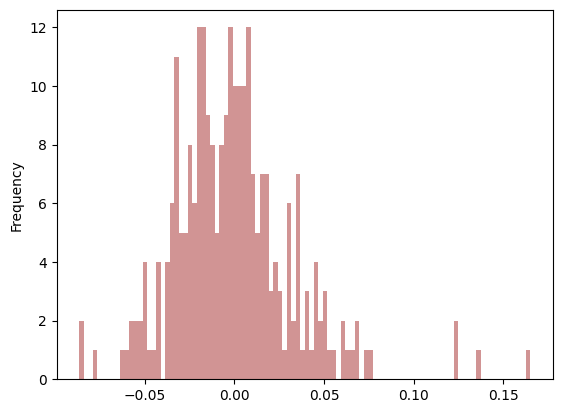

In [106]:
df_XiaoMi['Return'].plot.hist(bins=100,alpha=0.5, color='brown') # alpha 係透明不

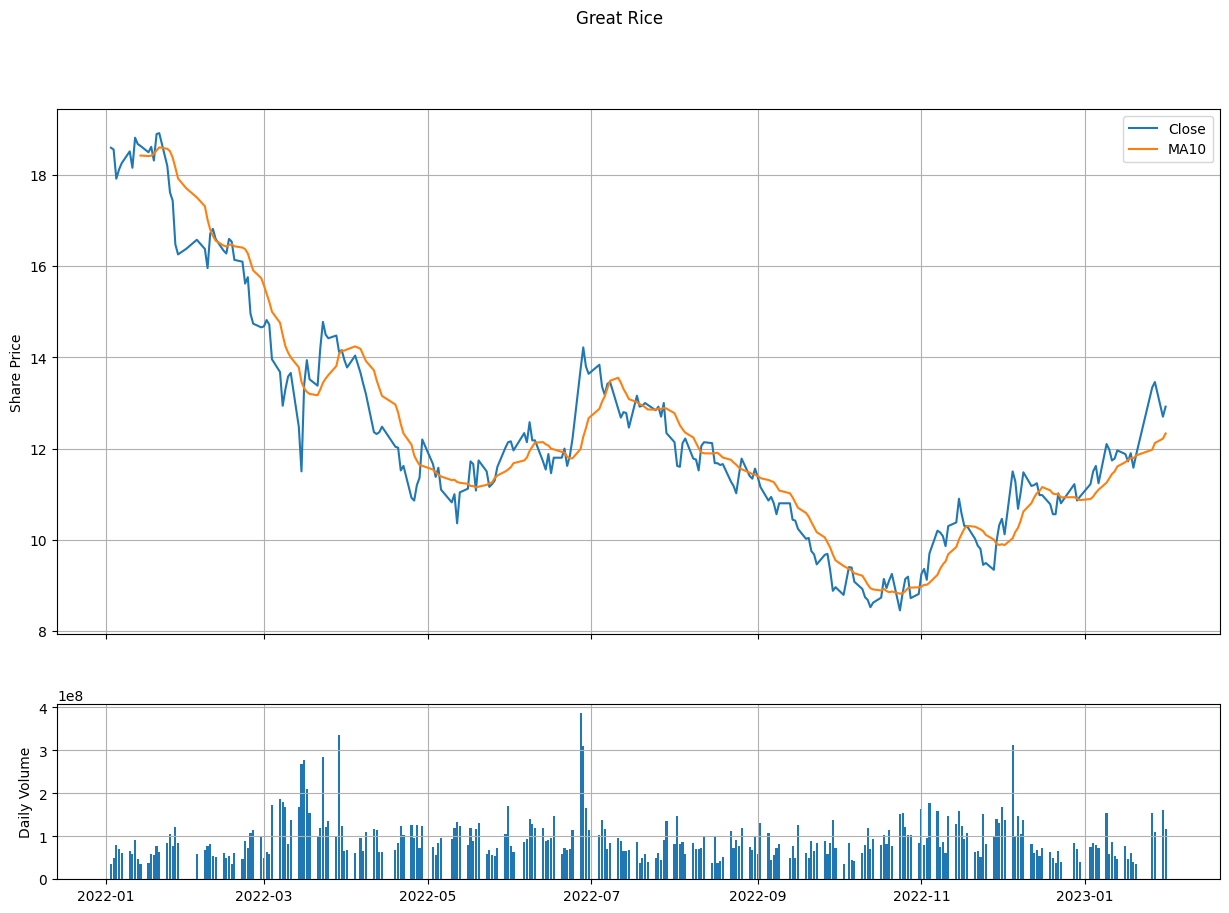

In [107]:
import matplotlib.pyplot as plt
fig, (ax1,ax2)=plt.subplots(2,1,sharex=True,figsize=(15,10),gridspec_kw={'height_ratios':[3,1]})

ax1.plot(df_XiaoMi.index, df_XiaoMi['Close'],df_XiaoMi['MA10'])
ax1.set_ylabel('Share Price')
ax1.legend(['Close','MA10'])

ax2.bar(df_XiaoMi.index,df_XiaoMi['Volume'])
ax2.set_ylabel('Daily Volume')

ax1.grid(True)
ax2.grid(True)

fig.suptitle('Great Rice')

plt.show()







In [108]:
import sqlite3
query="""
CREATE TABLE sales(
firstname VARCHAR(20),
lastname VARCHAR(20),
age INTEGER,
sales REAL
);
"""


In [109]:
con=sqlite3.connect('sales.sqlite')  # Create Database
con.execute(query)    # Create Table

OperationalError: table sales already exists

In [110]:
con.commit()

In [111]:
DaTTa=[('David','Chan',35,6800.50),('Edgar','Doe',45,79000.60),('Fion','Elle',35,69000.5),]
stmt="INSERT INTO sales values (?,?,?,?)"  #呢緊有四样嘢入four Entry is comming.
con.executemany(stmt,DaTTa)

In [112]:
con.commit()

In [113]:
cursor=con.execute('select*from sales')
rows=cursor.fetchall()
rows
cursor.description



(('firstname', None, None, None, None, None, None),
 ('lastname', None, None, None, None, None, None),
 ('age', None, None, None, None, None, None),
 ('sales', None, None, None, None, None, None))

In [114]:
import pandas as pd
import numpy as np
import requests
import os   # 要裝python-dotenv
import math
import plotly.express as px

Dff1=pd.DataFrame(data={ "Name":["Alex","Bob","Chris"],"Age":[30,40,50] }, index=[1,2,3])
Dff1

#print(type(data))

Dddf1=pd.DataFrame(data=[['Alex',30],['Bob',40],['Chris',50],],columns=['name','age'],index=[1,2,3], )
Dddf1





,name,age
1,Alex,30
2,Bob,40
3,Chris,50


In [115]:
Dddf1

,name,age
1,Alex,30
2,Bob,40
3,Chris,50


In [116]:
Dddf1.name

1     Alex
2      Bob
3    Chris
Name: name, dtype: object

In [117]:
Dddf1.age

1    30
2    40
3    50
Name: age, dtype: int64

In [118]:
type(Dddf1)

pandas.core.frame.DataFrame

In [119]:
# create a dataframe of car models by two companies
Df_Df = pd.DataFrame({
    'Company': ['A', 'A', 'A', 'B', 'B', 'B', 'B'],
    'Model': ['A1', 'A2', 'A3', 'B1', 'B2', 'B3', 'B4'],
    'Year': [2019, 2020, 2021, 2018, 2019, 2020, 2021],
    'Transmission': ['Manual', 'Automatic', 'Automatic', 
            'Manual', 'Automatic', 'Automatic', 'Manual'],
    'EngineSize': [1.4, 2.0, 1.4, 1.5, 2.0, 1.5, 1.5],
    'MPG': [55.4, 67.3, 58.9, 52.3, 64.2, 68.9, 83.1]
})
# display the dataframe
Df_Df

,Company,Model,Year,Transmission,EngineSize,MPG
0,A,A1,2019,Manual,1.4,55.4
1,A,A2,2020,Automatic,2.0,67.3
2,A,A3,2021,Automatic,1.4,58.9
3,B,B1,2018,Manual,1.5,52.3
4,B,B2,2019,Automatic,2.0,64.2
5,B,B3,2020,Automatic,1.5,68.9
6,B,B4,2021,Manual,1.5,83.1


In [120]:
Df_Df.groupby(["Company"])["MPG"].max()

Company
A    67.3
B    83.1
Name: MPG, dtype: float64

In [121]:
type(Df_Df)

pandas.core.frame.DataFrame

In [122]:
Df_Df.groupby(["Company"])["MPG"].agg('max')

Company
A    67.3
B    83.1
Name: MPG, dtype: float64

In [123]:
Df_Df.groupby(["Company"])["MPG"].agg(['max','min','mean','count','std','median']) #累積

,max,min,mean,count,std,median
Company,,,,,,
A,67.3,55.4,60.533333,3,6.115826,58.90
B,83.1,52.3,67.125000,4,12.736921,66.55


In [124]:
DF_DF_Group=Df_Df.groupby(["Company"])["MPG"].max()

In [125]:
print(DF_DF_Group)

Company
A    67.3
B    83.1
Name: MPG, dtype: float64


In [126]:
type(DF_DF_Group)



pandas.core.series.Series

In [127]:
Df_Df=pd.concat(
   
    [
      Df_Df,pd.DataFrame(
    
    {"Company":["C"],"Model":["C1"],"Year":[2023],"Transmission":["Automatic"],"EngineSize":[1.8],"MPG":[70],
     
     
     
     
    })
     ],ignore_index=True
     )

Df_Df






,Company,Model,Year,Transmission,EngineSize,MPG
0,A,A1,2019,Manual,1.4,55.4
1,A,A2,2020,Automatic,2.0,67.3
2,A,A3,2021,Automatic,1.4,58.9
3,B,B1,2018,Manual,1.5,52.3
4,B,B2,2019,Automatic,2.0,64.2
5,B,B3,2020,Automatic,1.5,68.9
6,B,B4,2021,Manual,1.5,83.1
7,C,C1,2023,Automatic,1.8,70.0


In [128]:
Df_Df.iloc[5]  # Index Location 

Company                 B
Model                  B3
Year                 2020
Transmission    Automatic
EngineSize            1.5
MPG                  68.9
Name: 5, dtype: object

In [129]:
Df_Df.sort_values(by=["Year",'Company'],ascending=[True,False])

,Company,Model,Year,Transmission,EngineSize,MPG
3,B,B1,2018,Manual,1.5,52.3
4,B,B2,2019,Automatic,2.0,64.2
0,A,A1,2019,Manual,1.4,55.4
5,B,B3,2020,Automatic,1.5,68.9
1,A,A2,2020,Automatic,2.0,67.3
6,B,B4,2021,Manual,1.5,83.1
2,A,A3,2021,Automatic,1.4,58.9
7,C,C1,2023,Automatic,1.8,70.0


In [130]:
Df_Df.sort_values(by=["Year",'Company'],ascending=[False,True])

,Company,Model,Year,Transmission,EngineSize,MPG
7,C,C1,2023,Automatic,1.8,70.0
2,A,A3,2021,Automatic,1.4,58.9
6,B,B4,2021,Manual,1.5,83.1
1,A,A2,2020,Automatic,2.0,67.3
5,B,B3,2020,Automatic,1.5,68.9
0,A,A1,2019,Manual,1.4,55.4
4,B,B2,2019,Automatic,2.0,64.2
3,B,B1,2018,Manual,1.5,52.3


In [131]:
Df_Df.sort_values(by=['Company',"Year"],ascending=[True,False])

,Company,Model,Year,Transmission,EngineSize,MPG
2,A,A3,2021,Automatic,1.4,58.9
1,A,A2,2020,Automatic,2.0,67.3
0,A,A1,2019,Manual,1.4,55.4
6,B,B4,2021,Manual,1.5,83.1
5,B,B3,2020,Automatic,1.5,68.9
4,B,B2,2019,Automatic,2.0,64.2
3,B,B1,2018,Manual,1.5,52.3
7,C,C1,2023,Automatic,1.8,70.0


In [132]:
Df_Df.set_index('Model')

,Company,Year,Transmission,EngineSize,MPG
Model,,,,,
A1,A,2019,Manual,1.4,55.4
A2,A,2020,Automatic,2.0,67.3
A3,A,2021,Automatic,1.4,58.9
B1,B,2018,Manual,1.5,52.3
B2,B,2019,Automatic,2.0,64.2
B3,B,2020,Automatic,1.5,68.9
B4,B,2021,Manual,1.5,83.1
C1,C,2023,Automatic,1.8,70.0


# 

In [133]:
Df_Df.reset_index(drop=True)

,Company,Model,Year,Transmission,EngineSize,MPG
0,A,A1,2019,Manual,1.4,55.4
1,A,A2,2020,Automatic,2.0,67.3
2,A,A3,2021,Automatic,1.4,58.9
3,B,B1,2018,Manual,1.5,52.3
4,B,B2,2019,Automatic,2.0,64.2
5,B,B3,2020,Automatic,1.5,68.9
6,B,B4,2021,Manual,1.5,83.1
7,C,C1,2023,Automatic,1.8,70.0


In [134]:
Df_Df[["MPG","EngineSize","Transmission","Company","Model","Year"]]

,MPG,EngineSize,Transmission,Company,Model,Year
0,55.4,1.4,Manual,A,A1,2019
1,67.3,2.0,Automatic,A,A2,2020
2,58.9,1.4,Automatic,A,A3,2021
3,52.3,1.5,Manual,B,B1,2018
4,64.2,2.0,Automatic,B,B2,2019
5,68.9,1.5,Automatic,B,B3,2020
6,83.1,1.5,Manual,B,B4,2021
7,70.0,1.8,Automatic,C,C1,2023


In [135]:
Df_Df.columns


Index(['Company', 'Model', 'Year', 'Transmission', 'EngineSize', 'MPG'], dtype='object')

In [136]:
df.iloc[:,[5,4,3,0,1,2]]

IndexError: positional indexers are out-of-bounds

In [138]:
type(Df_Df["EngineSize"].unique())

numpy.ndarray

In [139]:
type(Df_Df["EngineSize"].unique)

method

In [140]:
Df_Df["EngineSize"].unique().tolist()

[1.4, 2.0, 1.5, 1.8]

In [146]:
Df_Df["EngineSize"].nunique()

4

Return

In [147]:
df['Year'].value_counts()

KeyError: 'Year'

In [148]:
link = "https://api.data.gov.hk/v2/filter?q=%7B%22resource%22%3A%22http%3A%2F%2Fwww.rvd.gov.hk%2Fdoc%2Fen%2Fstatistics%2Fhis_data_16.xls%22%2C%22section%22%3A1%2C%22format%22%3A%22json%22%7D"
樓data樓 = pd.read_json(link)

# change the column name

print('XXX')
'''
regjeprjpoe
'''

樓data樓


XXX


,年 Year,月 Month,一手買賣 數目 Primary Sales No.,一手買賣 總值 (百萬元) Primary Sales Consideration ($ million),二手買賣 數目 Secondary Sales No.,二手買賣 總值 (百萬元) Secondary Sales Consideration ($ million)
0,2002,1,2718,8218,5129,9966
1,2002,2,1506,4305,4189,8070
2,2002,3,1709,4190,3741,6795
3,2002,4,2543,6516,4866,8739
4,2002,5,2257,5844,5068,11097
...,...,...,...,...,...,...
261,2023,10,356,4805,1767,19693
262,2023,11,547,6318,2007,13352
263,2023,12,959,9684,1970,14640
264,2024,1,1003,8336,2474,19456


In [149]:
樓data樓 = 樓data樓.rename(columns = {'年 Year':'Year',
                              '月 Month':'Month',
                              '一手買賣 數目 Primary Sales No.':'FirstHandSales',
                              '一手買賣 總值 (百萬元) Primary Sales Consideration ($ million)':
                              'FirstConsideration',
                              '二手買賣 數目 Secondary Sales No.':'SecondHandSales',
                              '二手買賣 總值 (百萬元) Secondary Sales Consideration ($ million)':
                              'SecondConsideration'
    })
樓data樓 

,Year,Month,FirstHandSales,FirstConsideration,SecondHandSales,SecondConsideration
0,2002,1,2718,8218,5129,9966
1,2002,2,1506,4305,4189,8070
2,2002,3,1709,4190,3741,6795
3,2002,4,2543,6516,4866,8739
4,2002,5,2257,5844,5068,11097
...,...,...,...,...,...,...
261,2023,10,356,4805,1767,19693
262,2023,11,547,6318,2007,13352
263,2023,12,959,9684,1970,14640
264,2024,1,1003,8336,2474,19456


In [150]:
樓data樓.describe()

,Year,Month,FirstHandSales,FirstConsideration,SecondHandSales,SecondConsideration
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000
mean,2012.586466,6.462406,1362.390977,11468.804511,5025.078947,22952.097744
std,6.410049,3.472873,755.566101,7146.029865,2564.918133,10790.074047
min,2002.000000,1.000000,131.000000,545.000000,1573.000000,4174.000000
25%,2007.000000,3.000000,784.750000,5845.000000,3115.500000,14892.000000
50%,2013.000000,6.000000,1244.000000,9823.000000,4415.500000,21088.500000
75%,2018.000000,9.000000,1797.500000,15786.750000,6340.000000,30132.000000
max,2024.000000,12.000000,3958.000000,38342.000000,13206.000000,55275.000000


In [151]:
#Join Year and Month as new Column 
樓data樓['DateTime']=樓data樓["Year"].astype(str)+"-"+樓data樓["Month"].astype(str)

#Drop Year & Month 
樓data樓=樓data樓.drop(['Year','Month'],axis=1)

#Set Datatime as index
樓data樓=樓data樓.set_index('DateTime')

樓data樓 


,FirstHandSales,FirstConsideration,SecondHandSales,SecondConsideration
DateTime,,,,
2002-1,2718,8218,5129,9966
2002-2,1506,4305,4189,8070
2002-3,1709,4190,3741,6795
2002-4,2543,6516,4866,8739
2002-5,2257,5844,5068,11097
...,...,...,...,...
2023-10,356,4805,1767,19693
2023-11,547,6318,2007,13352
2023-12,959,9684,1970,14640


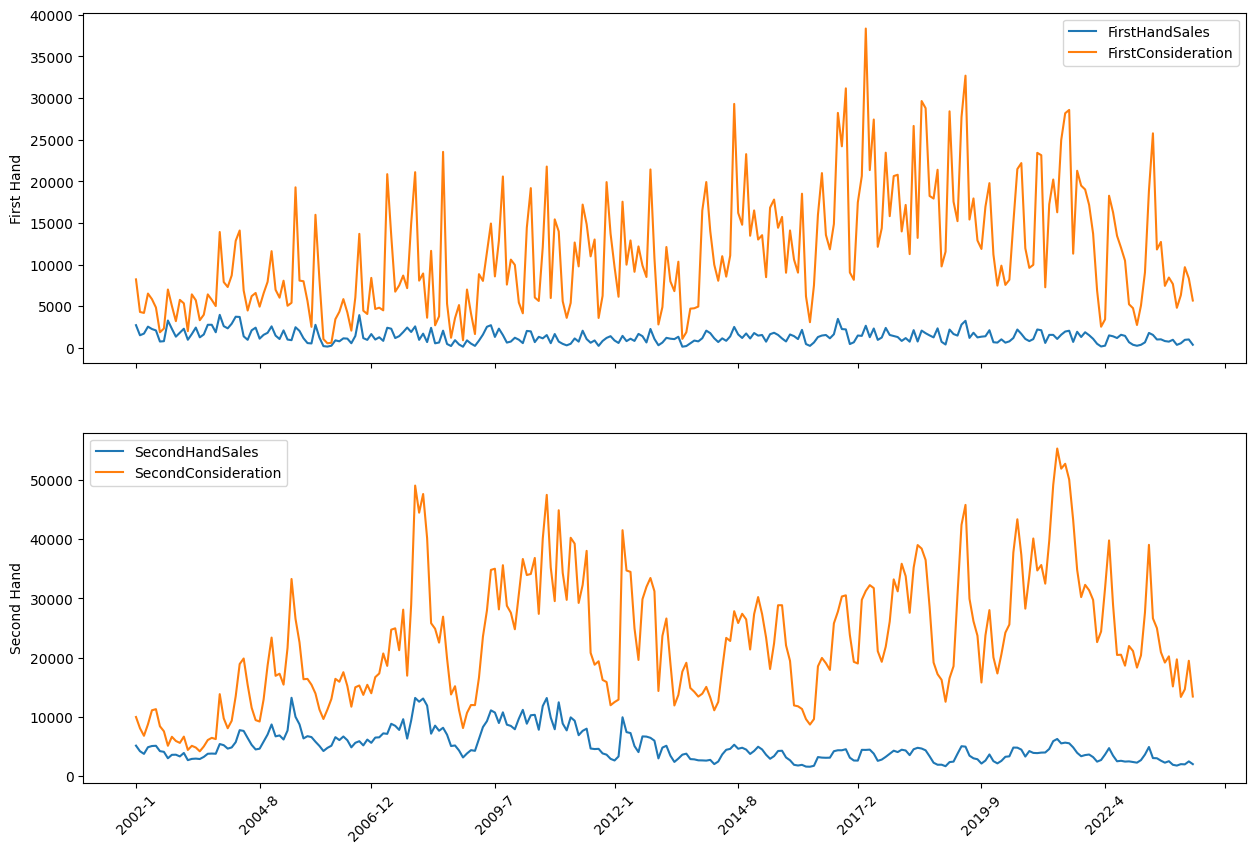

In [152]:
import matplotlib.pyplot as plt
from matplotlib.dates import AutoDateLocator ######

fig, (ax1,ax2) = plt.subplots(2,1, sharex=True, figsize=(15, 10),
                             gridspec_kw={'height_ratios':[1,1]})

ax1.plot( 樓data樓.index, 樓data樓['FirstHandSales'], 樓data樓['FirstConsideration'])
ax1.set_ylabel('First Hand')
ax1.legend(['FirstHandSales', 'FirstConsideration'])

ax2.plot( 樓data樓.index, 樓data樓['SecondHandSales'], 樓data樓['SecondConsideration'] )
ax2.set_ylabel('Second Hand')
ax2.legend(['SecondHandSales','SecondConsideration'])
ax2.xaxis.set_major_locator(AutoDateLocator(maxticks=15))   ####
ax2.xaxis.set_tick_params(rotation=45, )   ###


樓data樓['FirstAVG']=樓data樓['FirstConsideration']/樓data樓['FirstHandSales']
樓data樓['SecondAVG']=樓data樓['SecondConsideration']/樓data樓['SecondHandSales']


#ax2.plot( 樓data樓.index, 樓data樓['FirstAVG'], 樓data樓['SecondAVG'] )
#ax2.set_ylabel('FirstAVG'/'SecondAVG')
#ax2.legend(['FirstAVG','SecondAVG'])








# Compute Pairwise Correlation of Columns , excluding N/A null values

In [153]:
樓data樓.corr()['FirstHandSales']

FirstHandSales         1.000000
FirstConsideration     0.540893
SecondHandSales        0.131269
SecondConsideration    0.046023
FirstAVG              -0.338741
SecondAVG             -0.136764
Name: FirstHandSales, dtype: float64

In [154]:
樓data樓.corr()

,FirstHandSales,FirstConsideration,SecondHandSales,SecondConsideration,FirstAVG,SecondAVG
FirstHandSales,1.000000,0.540893,0.131269,0.046023,-0.338741,-0.136764
FirstConsideration,0.540893,1.000000,-0.014293,0.554104,0.478937,0.514893
SecondHandSales,0.131269,-0.014293,1.000000,0.491342,-0.197464,-0.483265
SecondConsideration,0.046023,0.554104,0.491342,1.000000,0.495400,0.471708
FirstAVG,-0.338741,0.478937,-0.197464,0.495400,1.000000,0.708352
SecondAVG,-0.136764,0.514893,-0.483265,0.471708,0.708352,1.000000


In [155]:
樓data樓.to_numpy()

array([[2.71800000e+03, 8.21800000e+03, 5.12900000e+03, 9.96600000e+03,
        3.02354673e+00, 1.94306882e+00],
       [1.50600000e+03, 4.30500000e+03, 4.18900000e+03, 8.07000000e+03,
        2.85856574e+00, 1.92647410e+00],
       [1.70900000e+03, 4.19000000e+03, 3.74100000e+03, 6.79500000e+03,
        2.45172616e+00, 1.81635926e+00],
       ...,
       [9.59000000e+02, 9.68400000e+03, 1.97000000e+03, 1.46400000e+04,
        1.00980188e+01, 7.43147208e+00],
       [1.00300000e+03, 8.33600000e+03, 2.47400000e+03, 1.94560000e+04,
        8.31106680e+00, 7.86418755e+00],
       [3.67000000e+02, 5.67700000e+03, 2.00800000e+03, 1.34190000e+04,
        1.54686649e+01, 6.68276892e+00]], shape=(266, 6))

In [156]:
樓data樓["FirstConsideration"].to_numpy()

array([ 8218,  4305,  4190,  6516,  5844,  4840,  1866,  2313,  7005,
        5032,  3202,  5757,  5342,  2001,  6418,  5710,  3314,  3975,
        6415,  5755,  5012, 13907,  7897,  7302,  8698, 12848, 14089,
        6884,  4476,  6199,  6587,  4941,  6544,  7923, 11607,  6967,
        6021,  8060,  5049,  5404, 19273,  8073,  7995,  5619,  2515,
       15974,  8178,  1047,   545,   604,  3440,  4334,  5848,  4238,
        2063,  6054, 13686,  4455,  4061,  8397,  4659,  4820,  4501,
       20854, 13487,  6745,  7493,  8677,  7163, 14913, 21092,  8066,
        8927,  3614, 11644,  2702,  3788, 23532,  5300,  1208,  3575,
        5135,   907,  6999,  4134,  1653,  8845,  8034, 11478, 14925,
        8574, 12865, 20575,  7593, 10592,  9954,  5433,  4143, 14432,
       19177,  6042,  5627, 12103, 21768,  5980, 15427, 13974,  5597,
        3597,  5391, 12647,  9778, 17200, 14850, 10980, 13007,  3586,
        6237, 19900, 13712,  9707,  6132, 17546,  9985, 12894,  9129,
       12177,  9889,

In [157]:
樓data樓.T

DateTime,2002-1,2002-2,2002-3,2002-4,2002-5,2002-6,2002-7,2002-8,2002-9,2002-10,...,2023-5,2023-6,2023-7,2023-8,2023-9,2023-10,2023-11,2023-12,2024-1,2024-2
FirstHandSales,2718.000000,1506.000000,1709.000000,2543.000000,2257.000000,2087.000000,755.000000,796.000000,3278.000000,2282.000000,...,1000.000000,1019.000000,810.000000,742.000000,964.000000,356.000000,547.000000,959.000000,1003.000000,367.000000
FirstConsideration,8218.000000,4305.000000,4190.000000,6516.000000,5844.000000,4840.000000,1866.000000,2313.000000,7005.000000,5032.000000,...,11807.000000,12718.000000,7438.000000,8440.000000,7663.000000,4805.000000,6318.000000,9684.000000,8336.000000,5677.000000
SecondHandSales,5129.000000,4189.000000,3741.000000,4866.000000,5068.000000,5108.000000,4206.000000,4085.000000,3000.000000,3581.000000,...,3003.000000,2594.000000,2255.000000,2505.000000,1898.000000,1767.000000,2007.000000,1970.000000,2474.000000,2008.000000
SecondConsideration,9966.000000,8070.000000,6795.000000,8739.000000,11097.000000,11289.000000,8406.000000,7554.000000,5108.000000,6626.000000,...,24961.000000,20903.000000,19153.000000,20205.000000,15124.000000,19693.000000,13352.000000,14640.000000,19456.000000,13419.000000
FirstAVG,3.023547,2.858566,2.451726,2.562328,2.589278,2.319118,2.471523,2.905779,2.136974,2.205083,...,11.807000,12.480864,9.182716,11.374663,7.949170,13.497191,11.550274,10.098019,8.311067,15.468665
SecondAVG,1.943069,1.926474,1.816359,1.795931,2.189621,2.210063,1.998573,1.849204,1.702667,1.850321,...,8.312021,8.058211,8.493570,8.065868,7.968388,11.144878,6.652715,7.431472,7.864188,6.682769


In [158]:
df_tnx=pd.read_csv("^TNX.csv")
df_tnx.tail(5)



,Date,Open,High,Low,Close,Adj Close,Volume
7057,2022-12-26,NaN,NaN,NaN,NaN,NaN,NaN
7058,2022-12-27,3.787,3.862,3.787,3.860,3.860,0.0
7059,2022-12-28,3.818,3.890,3.815,3.887,3.887,0.0
7060,2022-12-29,3.868,3.886,3.818,3.835,3.835,0.0
7061,2022-12-30,3.869,3.905,3.831,3.879,3.879,0.0


In [159]:

df_tnx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7062 entries, 0 to 7061
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       7062 non-null   object 
 1   Open       5780 non-null   float64
 2   High       5780 non-null   float64
 3   Low        5780 non-null   float64
 4   Close      5780 non-null   float64
 5   Adj Close  5780 non-null   float64
 6   Volume     5780 non-null   float64
dtypes: float64(6), object(1)
memory usage: 386.3+ KB


In [160]:



df_tnx['Date']=pd.to_datetime(df_tnx['Date'],format="%Y-%m-%d")
df_tnx=df_tnx.set_index('Date')
df_tnx.info()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7062 entries, 2000-01-03 to 2022-12-30
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       5780 non-null   float64
 1   High       5780 non-null   float64
 2   Low        5780 non-null   float64
 3   Close      5780 non-null   float64
 4   Adj Close  5780 non-null   float64
 5   Volume     5780 non-null   float64
dtypes: float64(6)
memory usage: 386.2 KB


In [161]:
df_tnx


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2000-01-03,6.498,6.603,6.498,6.548,6.548,0.0
2000-01-04,6.530,6.548,6.485,6.485,6.485,0.0
2000-01-05,6.521,6.599,6.508,6.599,6.599,0.0
2000-01-06,6.558,6.585,6.540,6.549,6.549,0.0
2000-01-07,6.545,6.595,6.504,6.504,6.504,0.0
...,...,...,...,...,...,...
2022-12-26,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-27,3.787,3.862,3.787,3.860,3.860,0.0
2022-12-28,3.818,3.890,3.815,3.887,3.887,0.0


In [162]:
Ddf_dtT=pd.DataFrame({'year':[2023,2023],'month':[1,1],'day':[1,2],'sales':[3750,3900]})


Ddf_dtT

,year,month,day,sales
0,2023,1,1,3750
1,2023,1,2,3900


In [163]:
pd.to_datetime(Ddf_dtT[['year','month','day']])



0   2023-01-01
1   2023-01-02
dtype: datetime64[ns]

In [164]:
pd.to_datetime(Ddf_dtT[['year','month','day']]).to_numpy()

array(['2023-01-01T00:00:00.000000000', '2023-01-02T00:00:00.000000000'],
      dtype='datetime64[ns]')

In [165]:
Ddf_dtT['date']=pd.to_datetime(Ddf_dtT[['year','month','day']])
DDdf_dtTT=Ddf_dtT.drop(['year','month','day'],axis=1)
DDdf_dtTT=Ddf_dtT.set_index('date')
DDdf_dtTT


,year,month,day,sales
date,,,,
2023-01-01,2023,1,1,3750
2023-01-02,2023,1,2,3900


In [166]:
pd.to_datetime(1681038343,unit='s')

Timestamp('2023-04-09 11:05:43')

In [167]:
pd.to_datetime(8049358430584,unit='ns')

Timestamp('1970-01-01 02:14:09.358430584')

In [168]:
animal=pd.Series(["Bird","Cat","Dog","Elephant"],dtype="category")

In [169]:
animal.info()

<class 'pandas.core.series.Series'>
RangeIndex: 4 entries, 0 to 3
Series name: None
Non-Null Count  Dtype   
--------------  -----   
4 non-null      category
dtypes: category(1)
memory usage: 340.0 bytes


In [170]:
df_exam=pd.DataFrame({'Score':np.random.randint(1,101,size=40)})

In [171]:
df_exam

,Score
0,32
1,39
2,83
3,90
4,39
5,88
6,7
7,79
8,56
9,35


In [172]:
np.where(df_exam["Score"]>70,'Distinction',
         
         np.where(df_exam['Score']>60,'Good',np.where(df_exam['Score']>=50,'Pass','Fail')
                 
                                                   )
        
        )





array(['Fail', 'Fail', 'Distinction', 'Distinction', 'Fail',
       'Distinction', 'Fail', 'Distinction', 'Pass', 'Fail', 'Fail',
       'Distinction', 'Distinction', 'Fail', 'Distinction', 'Distinction',
       'Distinction', 'Distinction', 'Fail', 'Distinction', 'Fail',
       'Good', 'Fail', 'Fail', 'Distinction', 'Good', 'Pass',
       'Distinction', 'Fail', 'Pass', 'Good', 'Fail', 'Fail',
       'Distinction', 'Fail', 'Pass', 'Distinction', 'Distinction',
       'Fail', 'Distinction'], dtype='<U11')

In [173]:
df_exam['Result']=pd.Series( np.where(df_exam['Score']>70,'Distinction', 
                                      np.where(df_exam['Score']>60, 'Good', 
                                         np.where(df_exam['Score']>=50,'Pass','Fails')     
                                                                                 ))).astype('category')




In [174]:
df_exam.Result.value_counts()

Result
Distinction    17
Fails          16
Pass            4
Good            3
Name: count, dtype: int64

In [175]:
df_exam.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   Score   40 non-null     int32   
 1   Result  40 non-null     category
dtypes: category(1), int32(1)
memory usage: 536.0 bytes
